In [1]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\envs\cellpose\python.exe


In [4]:
import numpy as np
from cellpose import io
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import os
import cv2
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

ModuleNotFoundError: No module named 'matplotlib'

In [5]:
io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

os.chdir("C:\\Users\\bilbolab\\Box\\duke_bilbo\\MemberFolders\\Ben\\statistical_learning\\datascience_projects\\microglia_ramification\\cellpose\\")

2025-12-16 10:41:13,669 [INFO] WRITING LOG OUTPUT TO C:\Users\bilbolab\.cellpose\run.log
2025-12-16 10:41:13,670 [INFO] 
cellpose version: 	4.0.8 
platform:       	win32 
python version: 	3.10.19 
torch version:  	2.9.1+cu126


NameError: name 'core' is not defined

In [34]:
# *** change to your google drive folder path ***
dir = "1024_v_2048"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images found in folder")

2 images found in folder


In [35]:
img = io.imread(files[0])
img = img.transpose(1, 2, 0)
print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (1024, 1024, 2). Assuming channel dimension is last with 2 channels


Channel Selection:
Use the dropdowns below to select the zero-indexed channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

If you have a histological image taken in brightfield, you don't need to adjust the channels.

If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to None. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

In [36]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]

(3050, 3050, 2)
2025-12-09 14:31:58,712 [INFO] processing image with (3050, 3050) HW, and 3 channels


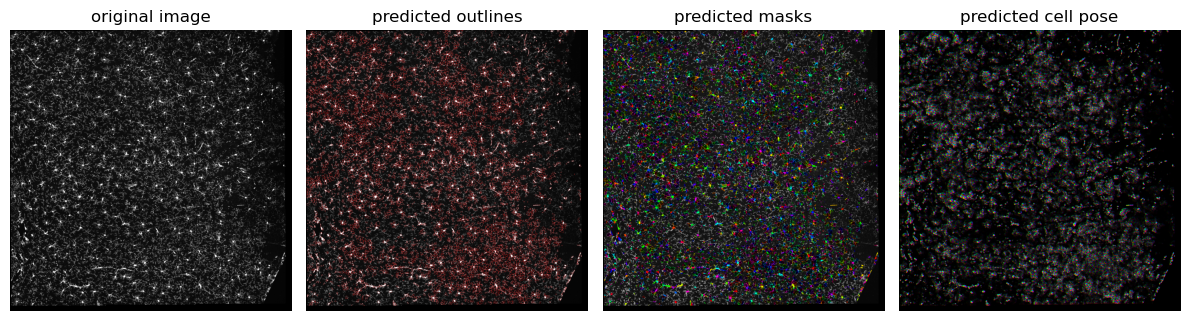

In [7]:
# selected_channels = []
# for i, c in enumerate([first_channel, second_channel, third_channel]):
#   if c == 'None':
#     continue
#   if int(c) > img.shape[0]:
#     assert False, 'invalid channel index, must have index greater or equal to the number of channels'
#   if c != 'None':
#     selected_channels.append(int(c))

# img_selected_channels = np.zeros_like(img)
# img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]

# flow_threshold = 0.8
# cellprob_threshold = -1
# tile_norm_blocksize = 0

# print(img_selected_channels.shape)

# masks, flows, styles = model.eval(img_selected_channels,  diameter = 50, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
#                                   normalize={"tile_norm_blocksize": tile_norm_blocksize})

# fig = plt.figure(figsize=(12,5))
# plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
# plt.tight_layout()
# plt.show()

In [37]:
def export_segmented_images(img):
    
    selected_channels = []
    for i, c in enumerate([first_channel, second_channel, third_channel]):
        if c == 'None':
            continue
        if int(c) > img.shape[0]:
            assert False, 'invalid channel index, must have index greater or equal to the number of channels'
        if c != 'None':
            selected_channels.append(int(c))

    img_selected_channels = np.zeros_like(img)
    img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]
    fig = plt.figure(figsize=(12,5))
    show_segmentation_modified(fig, img, masks, flows[0], file_name=f)

In [38]:
def mask_filter_fixed(masks, pix_size):
    for msk in np.unique(masks):
        if np.where(masks == msk)[1].shape[0] > pix_size:
            pass
        elif np.where(masks == msk)[1].shape[0] < pix_size:
            rows, cols = np.where(masks == msk)
            masks[rows, cols] = 0
    return masks

In [48]:
def save_segmentation_img_w_mask_ns_fixed(img, maski, file_name, odir):

    img0 = img.copy()
    
    if img0.shape[0] < 4:
        img0 = np.transpose(img0, (1, 2, 0))
    #if img0.shape[-1] < 3 or img0.ndim < 3:
        #img0 = image_to_rgb(img0, channels=[0, 0])
    else:
        if img0.max() <= 50.0:
            img0 = np.uint8(np.clip(img0, 0, 1) * 255)
    z = mask_overlay(img0, maski)
    
    my_dpi = 300
    plt.figure(figsize=(np.shape(img)[1]/my_dpi, np.shape(img)[2]/my_dpi), dpi = my_dpi)
    plt.axis("off")
    plt.imshow(z)    
    for cell in np.unique(masks):
        y, x = np.where(masks == cell)
        plt.text(int(np.median(x)), int(np.median(y)), str(cell), color="white", fontsize=4)
    plt.savefig(os.path.join(odir, str(file_name).split('_MIP')[0].split("\\")[1] + "_labelled_segmentations" + '.png'), dpi=my_dpi, bbox_inches = "tight")
    plt.close()

In [51]:
#### I have found that these parameters work really well for this model
#### They have been optimized for 20X images at 2048x2048 resolution (i.e. images from the zeiss)
#### It should work for 1024x1024 images taken on the confocal but will likely need to reduce the diameter by half or a little less than half (i.e. 250)

flow_threshold = 3
cellprob_threshold = -4
tile_norm_blocksize = 0
diam = 375
niterations = 3000

masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32, diameter = diam, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize}, niter=niterations)
   
    masks = mask_filter_fixed(masks, pix_size = 5000)
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)
    output_dir = str(f).split('\\')[1].split('.')[0] + '_outputs'



    os.mkdir(output_dir)
    print(output_dir + " making folder")

    save_segmentation_img_w_mask_ns_fixed(img, masks, file_name = f, odir = output_dir)

    for cell in np.unique(masks):
        if cell > 0:
            x, y = np.where(masks == cell)
            cropped = img[1][x.min():x.max(), y.min():y.max()]
            try:
                cv2.imwrite(os.path.join(output_dir, str(f).split('_MIP')[0].split("\\")[1] + "_cell_" + str(cell) + '.png'), cropped)
            except:
                pass


  0%|                                                           | 0/2 [00:00<?, ?it/s]

2025-12-16 10:10:16,323 [INFO] processing image with (1024, 1024) HW, and 3 channels


  0%|                                                           | 0/2 [00:06<?, ?it/s]

20X_microglia_test_1024_2_A01_G001_0001_outputs making folder


NameError: name 'mask_overlay' is not defined

In [28]:
x, y = np.where(masks == cell)

NameError: name 'cell' is not defined

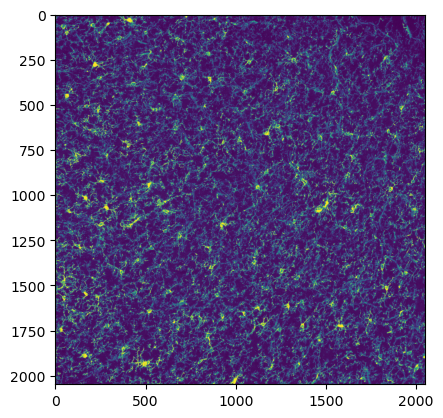

In [24]:
plt.imshow(img[1])

In [25]:
x

NameError: name 'x' is not defined

In [40]:
def show_segmentation_modified(fig, img, maski, flowi, channels=[0, 0], file_name=None):
    """Plot segmentation results (like on website).

    Can save each panel of figure with file_name option. Use channels option if
    img input is not an RGB image with 3 channels.

    Args:
        fig (matplotlib.pyplot.figure): Figure in which to make plot.
        img (ndarray): 2D or 3D array. Image input into cellpose.
        maski (int, ndarray): For image k, masks[k] output from Cellpose.eval, where 0=NO masks; 1,2,...=mask labels.
        flowi (int, ndarray): For image k, flows[k][0] output from Cellpose.eval (RGB of flows).
        channels (list of int, optional): Channels used to run Cellpose, no need to use if image is RGB. Defaults to [0, 0].
        file_name (str, optional): File name of image. If file_name is not None, figure panels are saved. Defaults to None.
        seg_norm (bool, optional): Improve cell visibility under labels. Defaults to False.
    """

    ax = fig.add_subplot(1, 4, 1)
    img0 = img.copy()

    if img0.shape[0] < 4:
        img0 = np.transpose(img0, (1, 2, 0))
    if img0.shape[-1] < 3 or img0.ndim < 3:
        img0 = image_to_rgb(img0, channels=channels)
    else:
        if img0.max() <= 50.0:
            img0 = np.uint8(np.clip(img0, 0, 1) * 255)
    ax.imshow(img0)
    ax.set_title("original image")
    ax.axis("off")

    outlines = utils.masks_to_outlines(maski)

    overlay = mask_overlay(img0, maski)

    # ax = fig.add_subplot(1, 4, 2)
    # outX, outY = np.nonzero(outlines)
    # imgout = img0.copy()
    # imgout[outX, outY] = np.array([255, 0, 0])  # pure red

    # ax.imshow(imgout)
    # ax.set_title("predicted outlines")
    # ax.axis("off")

    # ax = fig.add_subplot(1, 4, 3)
    # ax.imshow(overlay)
    # ax.set_title("predicted masks")
    # ax.axis("off")

    # ax = fig.add_subplot(1, 4, 4)
    # ax.imshow(flowi)
    # ax.set_title("predicted cell pose")
    # ax.axis("off")

    if file_name is not None:
        save_path = os.path.splitext(file_name)[0]
        io.imsave(save_path + "_overlay.jpg", overlay)